# Task 2.1.7: Task 7: Real-Life Examples of Object Detection
## Case studies and examples of object detection in real-world applications of CV and AI

Some applications where CV and AI are used to tackle real world problems.

In [1]:
# Importing required libraries, which include:
# OpenCV library used for the many tasks in computer vision, from loading images, to processing, detecting, shapes, tracking objects etc.:
import cv2
# Numpy is very useful computation library, here we can use it to compute means:
import numpy as np
# We need the following to show images as plots (x and y axes), later we will use it to draw actual plots too:
import matplotlib.pyplot as plt
# We need the following to draw areas of interest on our plots and images:
import matplotlib.patches as patches

### Case Study 1: Retail – Shelf Stock Monitoring

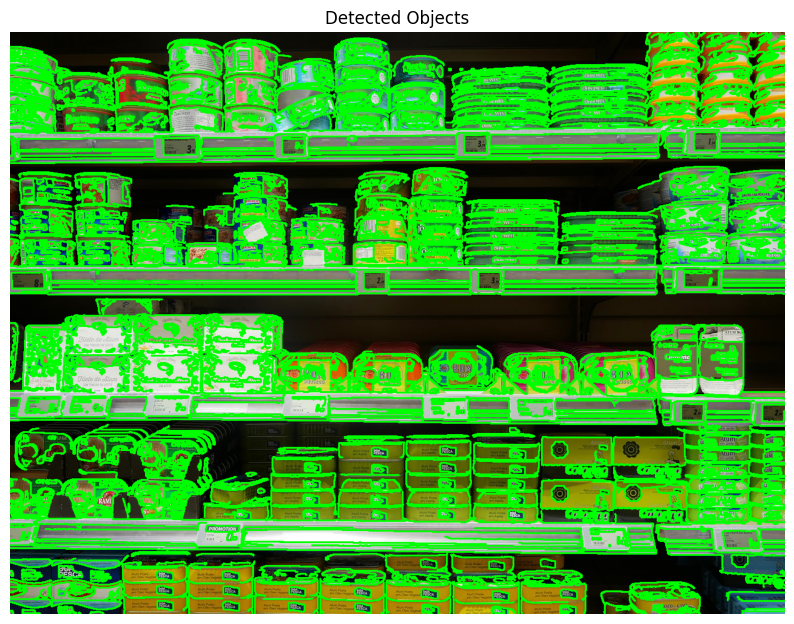

In [3]:
# Case Study 1: Retail – Shelf Stock Monitoring
# Use Canny edge detector to detect the contours of items on a shelf

# Load an image
image_path = "data/shelf1.jpg"
image = cv2.imread(image_path)

# Preprocess image

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Apply GaussianBlur to reduce noise and improve contour detection

blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# Detect edges using Canny

edges = cv2.Canny(blurred, 50, 150)

# Find contours

contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)


# Filter and process each contour
output = image.copy()
cv2.drawContours(output, contours, -1, (0, 255, 0), 2)

# Display the result
output_rgb = cv2.cvtColor(output, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 8))
plt.imshow(output_rgb)
plt.title("Detected Objects")
plt.axis("off")
plt.show()

### Case Study 2: Security - Facial Detection Within Scene

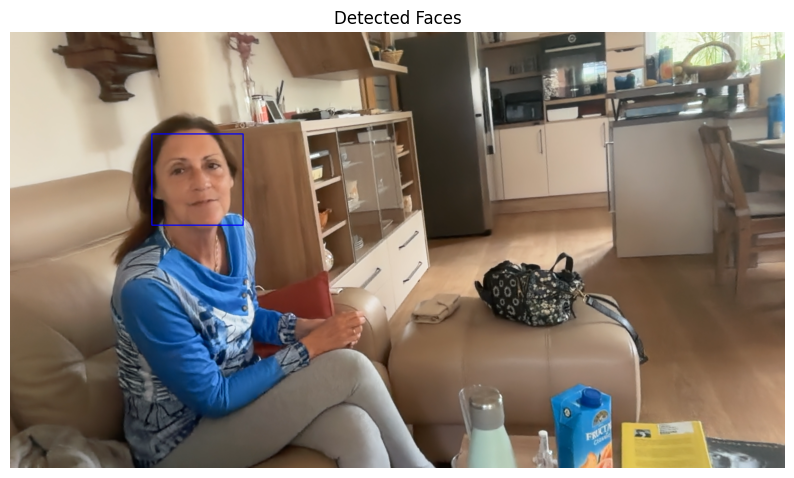

In [45]:
# Case Study 2: Security - Facial Detection Within Scene

# Define the function that accepts an image and uses cv2.CascadeClassifier to perform facial deteciton.
def detect_faces(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)

    for (x, y, w, h) in faces:
        cv2.rectangle(image, (x, y), (x + w, y + h), (255, 0, 0), 2)

    output_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 8))
    plt.imshow(output_rgb)
    plt.title("Detected Faces")
    plt.axis("off")
    plt.show()

# Access the webcam and capture an image
cap = cv2.VideoCapture(0)  # 0 is for default camera

# Check if webcam has been successfully accessed
if not cap.isOpened():
    print("Webcam not accessible. Using a locally stored image instead.")
    frame = cv2.imread('data/VOCFace1.jpg')  # Replace 'path_to_local_image.jpg' with the path to your local image
    if frame is None:
        print("Error loading local image.")
        exit()
else:
    ret, frame = cap.read()  # Capture a single frame
    cap.release()  # Release the camera

    if not ret:
        print("Failed to grab frame from webcam.")
        exit()

detect_faces(frame)

### Case Study 3: Manufacturing - Detecting Defects on Metal Surfaces

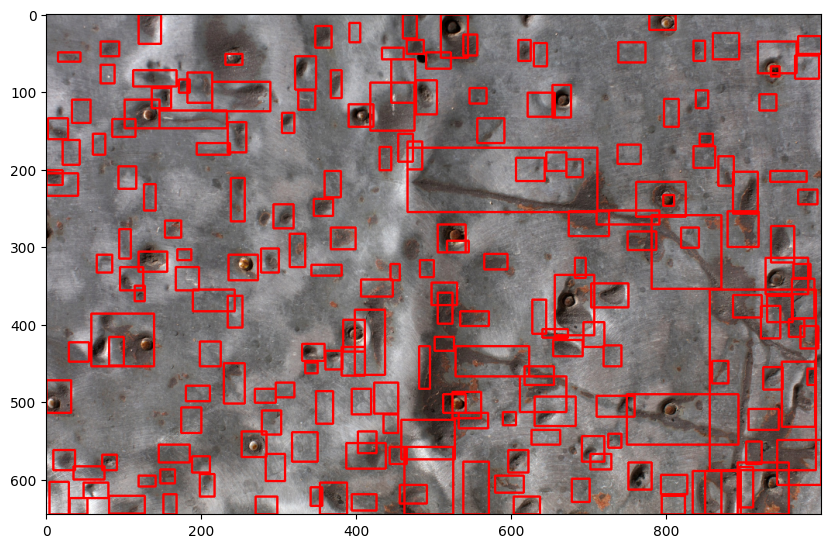

In [36]:
# Case Study 3: Manufacturing - Detecting Defects on Metal Surfaces

# Load the image
image_path = "data/metal1.jpg"
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_og = img.copy()

# Convert to grayscale

gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# Adaptive thresholding to highlight defects

thresh = cv2.adaptiveThreshold(blurred, 799, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 11, 2)

# Find contours

contours = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)[0]

# Filter out small noise by area

filtered_contours = [cnt for cnt in contours if cv2.contourArea(cnt) > 100]

# Draw contours on the original image

for cnt in filtered_contours:
    x, y, w, h = cv2.boundingRect(cnt)
    cv2.rectangle(img_og, (x, y), (x + w, y + h), (255, 0, 0), 2)

# Display the result



plt.figure(figsize=(10, 8))
plt.imshow(img_og)
plt.show()